# Finite-Horizon Dynamic Programming

Backward induction over $T=2000$ periods. Each period the player chooses among work, the 1/2 game, and the 2/5 game. The terminal value is $V_T(x) = x$ (risk-neutral), and the model is solved backwards to $V_0$.

**Key question:** At what bankroll should we move up from 1/2 to 2/5?

## Imports and style

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

FIG_DIR = Path("../quarto/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── clean matplotlib style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "lines.linewidth": 1.8,
})

## Parameters

In [2]:
from brm import OptimalBRM, calc_eta

# ── model parameters ────────────────────────────────────────────────────────
B     = [0,   200, 500]   # buyin sizes ($)
mu    = [7,    12,  20]   # mean hourly gain ($/hr)
sigma = [0,    80, 250]   # hourly std dev  ($/hr)
T     = 2000              # number of periods
xmax  = 1e6               # maximum bankroll on the grid ($)
xmin  = 1                 # minimum bankroll on the grid ($)
gridsize = 100            # number of grid points

GAME_LABELS = ["work ($7/hr)", "1/2 ($12/hr)", "2/5 ($20/hr)"]
T_PLOT = [0, 1950, 1999]  # periods to highlight in plots

## Solve the model

In [3]:
model = OptimalBRM(B, mu, sigma, T=T)
model.solve(xmax=xmax, gridsize=gridsize, xmin=xmin)

xgrid = model.xgrid
print(f"Grid: {gridsize} points from ${xgrid[0]:,.0f} to ${xgrid[-1]:,.0f}")
print(f"Value function shape: {model.Vt.shape}  (T x gridsize)")
print(f"Policy shape:         {model.ft.shape}")

Grid: 100 points from $1 to $1,000,000
Value function shape: (2000, 100)  (T x gridsize)
Policy shape:         (2000, 100)


## Optimal policy $f_t(x)$

The optimal game as a function of bankroll for three representative periods. As $t \to T$ the player becomes increasingly risk-neutral because the horizon is short and optionality has little time to compound.

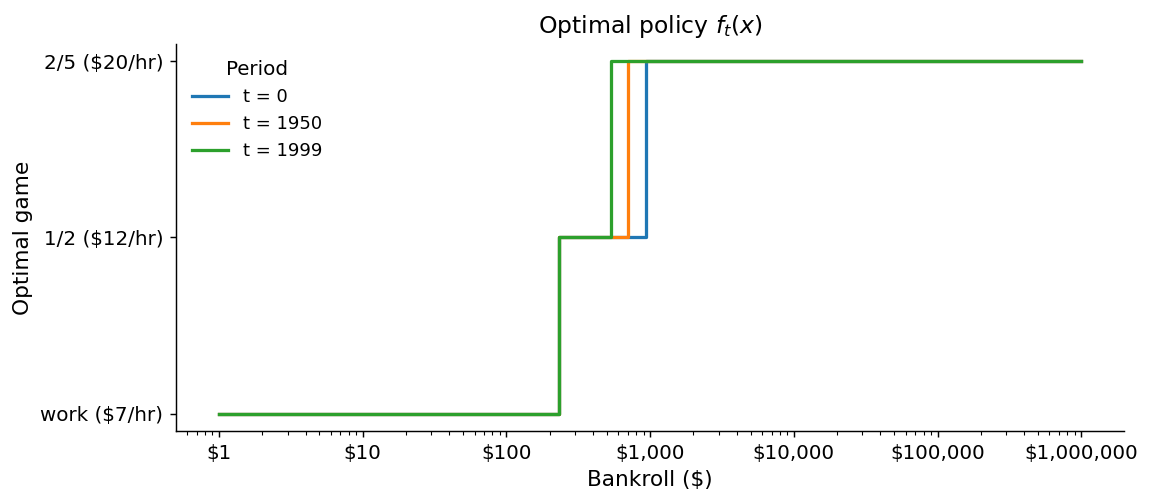

In [4]:
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots()
for t, c in zip(T_PLOT, COLORS):
    ax.step(xgrid, model.ft[t, :], where="post", color=c, lw=1.8, label=f"t = {t}")

ax.set_xscale("log")
ax.set_xlabel("Bankroll ($)")
ax.set_ylabel("Optimal game")
ax.set_title("Optimal policy $f_t(x)$")
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(GAME_LABELS)
ax.legend(title="Period")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.tight_layout()
fig.savefig(FIG_DIR / "finite_dp_policy.png", bbox_inches="tight")
plt.show()

## Value function $V_t(x)$

On a log–log scale the value function curves upward relative to the risk-neutral benchmark $V=x$, reflecting the option value of moving up in stakes.

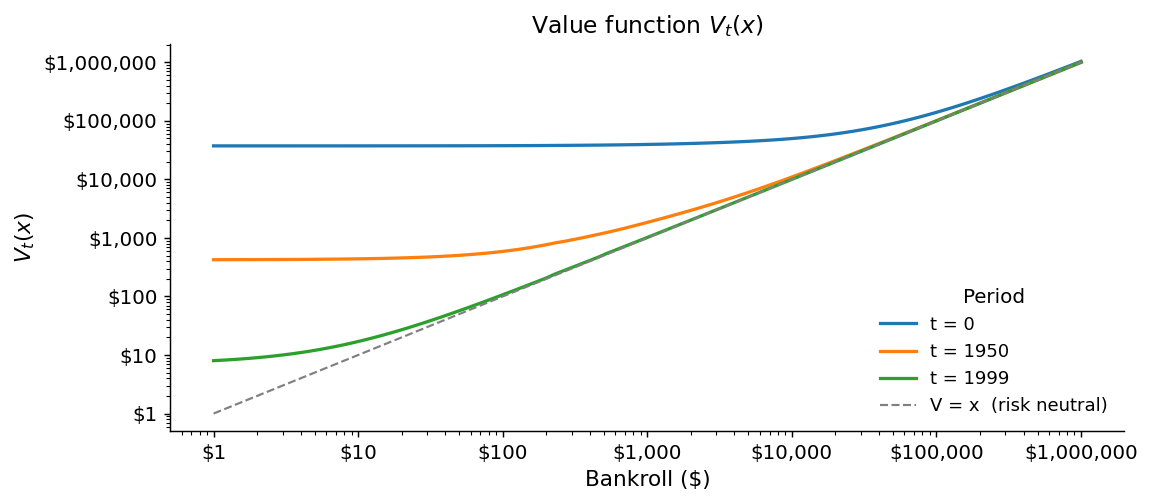

In [5]:
fig, ax = plt.subplots()
for t, c in zip(T_PLOT, COLORS):
    ax.plot(xgrid, model.Vt[t, :], color=c, lw=1.8, label=f"t = {t}")
# risk-neutral benchmark: V(x) = x
ax.plot(xgrid, xgrid, "--", color="gray", lw=1.2, label="V = x  (risk neutral)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Bankroll ($)")
ax.set_ylabel("$V_t(x)$")
ax.set_title("Value function $V_t(x)$")
ax.legend(title="Period")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.tight_layout()
fig.savefig(FIG_DIR / "finite_dp_vf.png", bbox_inches="tight")
plt.show()

## Implied CRRA coefficient $\eta(x)$

Recovered by inverting the local ratio of CRRA utilities at consecutive grid points. Values above the $\eta=1$ line indicate greater risk aversion than log utility; the coefficient falls toward zero as the bankroll grows and optionality saturates.

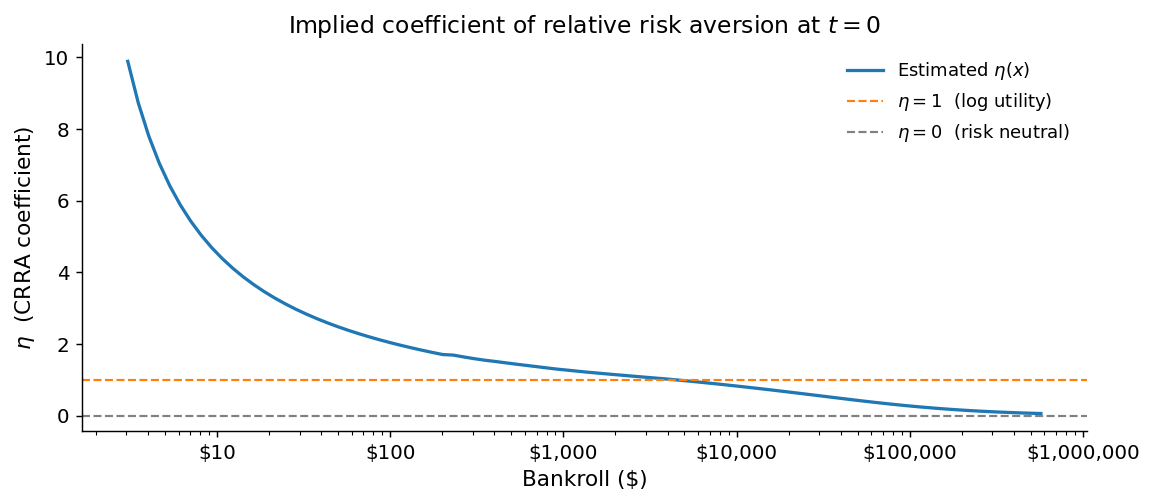

      Bankroll    eta
------------------------
  $      1,000    1.297
  $      5,000    0.980
  $     20,000    0.661
  $    100,000    0.286
  $  1,000,000    0.036


In [6]:
eta = calc_eta(xgrid, model.Vt[0, :])

# Trim boundary artefacts (fsolve is noisy near the grid edges)
trim = slice(8, -4)
x_plot   = xgrid[trim]
eta_plot = eta[trim]

fig, ax = plt.subplots()
ax.plot(x_plot, eta_plot, color="#1f77b4", lw=1.8, label="Estimated $\\eta(x)$")
ax.axhline(1, ls="--", color="#ff7f0e", lw=1.2, label="$\\eta = 1$  (log utility)")
ax.axhline(0, ls="--", color="gray",    lw=1.2, label="$\\eta = 0$  (risk neutral)")

ax.set_xscale("log")
ax.set_xlabel("Bankroll ($)")
ax.set_ylabel("$\\eta$  (CRRA coefficient)")
ax.set_title("Implied coefficient of relative risk aversion at $t = 0$")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
fig.tight_layout()
fig.savefig(FIG_DIR / "finite_dp_eta.png", bbox_inches="tight")
plt.show()

# ── spot-check table ────────────────────────────────────────────────────────
print(f"{'Bankroll':>14}    eta")
print("-" * 24)
for x_tgt in [1_000, 5_000, 20_000, 100_000, 1_000_000]:
    idx = int(np.argmin(np.abs(xgrid - x_tgt)))
    print(f"  ${x_tgt:>11,.0f}    {eta[idx]:.3f}")